# Avaliação do Modelo de Detecção de Fraudes

**FIA Business School | LABDATA | Banco FIA MBA Digital**

Este notebook realiza a avaliação detalhada do modelo treinado, incluindo:

1. **Métricas de Classificação** - ROC-AUC, Precision-Recall, F1-Score
2. **Matriz de Confusão** - Visualização e análise
3. **Curva ROC e Precision-Recall** - Gráficos
4. **Feature Importance** - Top features do modelo
5. **Análise de Erros** - Falsos positivos/negativos
6. **Interpretabilidade (SHAP)** - Se disponível


In [ ]:
# Imports
import json
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    auc,
    confusion_matrix,
    roc_curve,
    classification_report,
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

# Paths
cwd = Path.cwd().resolve()
if (cwd / 'Model').exists() and (cwd / 'Dados').exists():
    PROJECT_ROOT = cwd
    MODEL_DIR = cwd / 'Model'
elif cwd.name == 'Model':
    PROJECT_ROOT = cwd.parent
    MODEL_DIR = cwd
else:
    PROJECT_ROOT = cwd
    MODEL_DIR = cwd / 'Model' if (cwd / 'Model').exists() else cwd

MODEL_PATH = MODEL_DIR / 'fraud_model.pkl'
METRICS_PATH = MODEL_DIR / 'training_metrics.json'
ABT_PATH = PROJECT_ROOT / 'Dados' / 'abt.csv'
CONFIG_PATH = MODEL_DIR / 'model_config.json'

print(f"Model: {MODEL_PATH.exists()}")
print(f"Metrics: {METRICS_PATH.exists()}")
print(f"ABT: {ABT_PATH.exists()}")

Model: True
Metrics: True
ABT: True


In [ ]:
# Carregar modelo e métricas
with open(MODEL_PATH, 'rb') as f:
    model = pickle.load(f)

with open(METRICS_PATH, 'r') as f:
    metrics = json.load(f)

with open(CONFIG_PATH, 'r') as f:
    config = json.load(f)

print("Modelo carregado com sucesso!")
#print(f"Best iteration: {model.best_iteration}")
#print(f"n_estimators: {model.n_estimators}")
print()
print("Métricas salvas:")
for k, v in metrics.items():
    if k not in ['confusion_matrix', 'feature_importance_top20']:
        print(f"  {k}: {v}")

Modelo carregado com sucesso!

Métricas salvas:
  model_config: {'model': {'algorithm': 'XGBoost', 'library': 'xgboost', 'version': '2.0.0', 'task': 'binary_classification'}, 'hyperparameters': {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 28.8, 'random_state': 42, 'n_jobs': -1, 'eval_metric': 'auc', 'tree_method': 'hist'}, 'training': {'target_column': 'isFraud', 'test_size': 0.2, 'random_state': 42, 'stratify': True, 'early_stopping_rounds': 20, 'validation_split': 0.1, 'cv_folds': 5}, 'evaluation': {'metrics': ['roc_auc', 'precision', 'recall', 'f1', 'precision_recall_auc', 'confusion_matrix'], 'threshold_optimization': 'f1'}, 'metadata': {'created_at': '2026-06-27', 'project': 'Fraud Detection - IEEE-CIS', 'institution': 'FIA Business School - LABDATA', 'version': '1.0.0'}}
  best_params: {'n_estimators': 782, 'max_depth': 9, 'learning_rate': 0.24420460844911424, 'subsample': 0.9579309401710595, 'colsample

In [ ]:
# Carregar ABT e separar teste
df = pd.read_csv(rf'{ABT_PATH}')
target_col = config['training']['target_column']
test_size = config['training']['test_size']
random_state = config['training']['random_state']
stratify = config['training']['stratify']

from sklearn.model_selection import train_test_split

X = df.drop(columns=[target_col])
y = df[target_col]

_train, X_test, _train_y, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=random_state,
    stratify=y if stratify else None
)

print(f"Test set: {X_test.shape[0]:,} samples")
print(f"Fraud rate: {y_test.mean()*100:.2f}%")

Test set: 118,108 samples
Fraud rate: 3.50%


In [ ]:
model

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8391599915244341
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
# Predições no conjunto de teste
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# Recalcular métricas
roc_auc = roc_auc_score(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall_vals, precision_vals)

cm = confusion_matrix(y_test, y_pred)

print(f"ROC-AUC:     {roc_auc:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1-Score:    {f1:.4f}")
print(f"PR-AUC:      {pr_auc:.4f}")
print()
print("Matriz de Confusão:")
print(cm)
print()
print(classification_report(y_test, y_pred, target_names=['Legítima', 'Fraude']))

ROC-AUC:     0.9668
Precision:   0.8347
Recall:      0.7476
F1-Score:    0.7888
PR-AUC:      0.8388

Matriz de Confusão:
[[113363    612]
 [  1043   3090]]

              precision    recall  f1-score   support

    Legítima       0.99      0.99      0.99    113975
      Fraude       0.83      0.75      0.79      4133

    accuracy                           0.99    118108
   macro avg       0.91      0.87      0.89    118108
weighted avg       0.99      0.99      0.99    118108



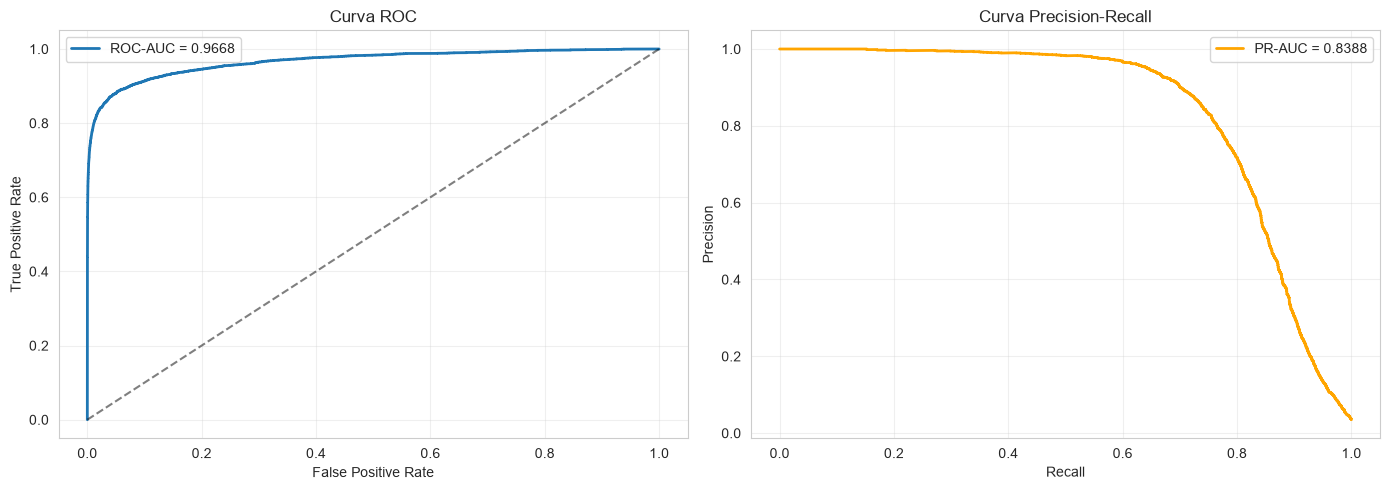

In [ ]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
axes[0].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.4f}', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall
axes[1].plot(recall_vals, precision_vals, label=f'PR-AUC = {pr_auc:.4f}', linewidth=2, color='orange')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

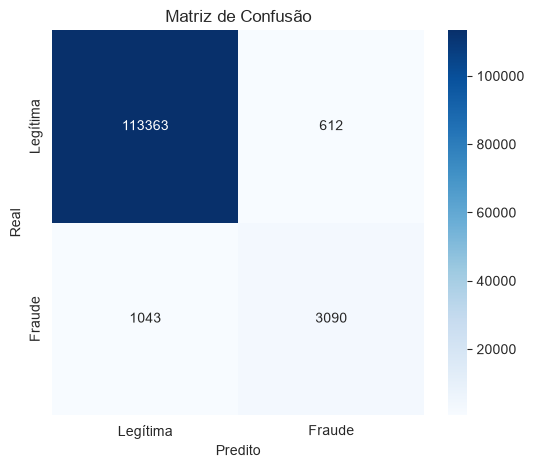

In [ ]:
# Matriz de Confusão - Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legítima', 'Fraude'],
            yticklabels=['Legítima', 'Fraude'],
            ax=ax)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão')
plt.show()

In [ ]:
# # Feature Importance - Top 20
# importance_df = pd.DataFrame(metrics['feature_importance_top20'])

# fig, ax = plt.subplots(figsize=(10, 8))
# sns.barplot(data=importance_df, x='importance', y='feature', ax=ax, palette='viridis')
# ax.set_xlabel('Importância (Gain)')
# ax.set_ylabel('Feature')
# ax.set_title('Top 20 Features - Importância do Modelo')
# plt.tight_layout()
# plt.show()

# print(importance_df.to_string(index=False))

Best threshold (F1): 0.6155
Best F1: 0.7929
Precision @ best: 0.8764
Recall @ best: 0.7239


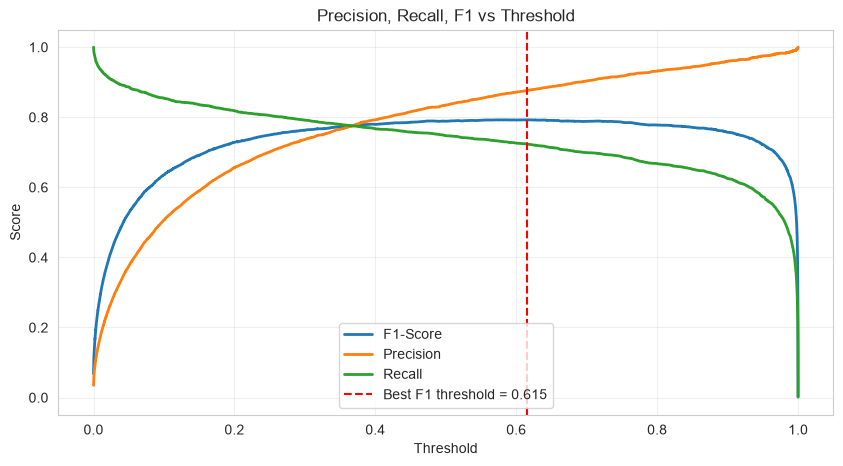

In [ ]:
# Análise de Threshold - Otimização de F1
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Calcular F1 para cada threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
best_f1 = f1_scores[best_idx]

print(f"Best threshold (F1): {best_threshold:.4f}")
print(f"Best F1: {best_f1:.4f}")
print(f"Precision @ best: {precisions[best_idx]:.4f}")
print(f"Recall @ best: {recalls[best_idx]:.4f}")

# Gráfico F1 vs Threshold
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1_scores[:-1], label='F1-Score', linewidth=2)
ax.plot(thresholds, precisions[:-1], label='Precision', linewidth=2)
ax.plot(thresholds, recalls[:-1], label='Recall', linewidth=2)
ax.axvline(best_threshold, color='red', linestyle='--', label=f'Best F1 threshold = {best_threshold:.3f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision, Recall, F1 vs Threshold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Predições com threshold otimizado
y_pred_opt = (y_pred_proba >= 0.2).astype(int)

cm_opt = confusion_matrix(y_test, y_pred_opt)
print("Matriz de Confusão (threshold otimizado):")
print(cm_opt)
print()
print(classification_report(y_test, y_pred_opt, target_names=['Legítima', 'Fraude']))

Matriz de Confusão (threshold otimizado):
[[112205   1770]
 [   751   3382]]

              precision    recall  f1-score   support

    Legítima       0.99      0.98      0.99    113975
      Fraude       0.66      0.82      0.73      4133

    accuracy                           0.98    118108
   macro avg       0.82      0.90      0.86    118108
weighted avg       0.98      0.98      0.98    118108



In [ ]:
# # Análise de Erros - Falsos Positivos e Falsos Negativos
# errors = X_test.copy()
# errors['true'] = y_test.values
# errors['pred'] = y_pred
# errors['proba'] = y_pred_proba

# false_positives = errors[(errors['true'] == 0) & (errors['pred'] == 1)]
# false_negatives = errors[(errors['true'] == 1) & (errors['pred'] == 0)]

# print(f"Falsos Positivos (legítima classificada como fraude): {len(false_positives):,}")
# print(f"Falsos Negativos (fraude classificada como legítima): {len(false_negatives):,}")

# # Top features para falsos positivos e negativos
# if 'feature' in importance_df.columns:
#     top_feats = [feat for feat in importance_df['feature'].head(10).tolist() if feat in X_test.columns]
# else:
#     top_feats = []

# if len(top_feats) == 0:
#     print("\nNenhuma feature compatível foi encontrada para comparar os erros.")
# else:
#     if len(false_positives) > 0:
#         print("\nMédias das top features - Falsos Positivos vs Geral:")
#         for feat in top_feats:
#             fp_mean = false_positives[feat].mean()
#             all_mean = X_test[feat].mean()
#             print(f"  {feat}: FP={fp_mean:.4f}, All={all_mean:.4f}, Diff={fp_mean-all_mean:.4f}")

#     if len(false_negatives) > 0:
#         print("\nMédias das top features - Falsos Negativos vs Geral:")
#         for feat in top_feats:
#             fn_mean = false_negatives[feat].mean()
#             all_mean = X_test[feat].mean()
#             print(f"  {feat}: FN={fn_mean:.4f}, All={all_mean:.4f}, Diff={fn_mean-all_mean:.4f}")

Falsos Positivos (legítima classificada como fraude): 612
Falsos Negativos (fraude classificada como legítima): 1,043


NameError: name 'importance_df' is not defined

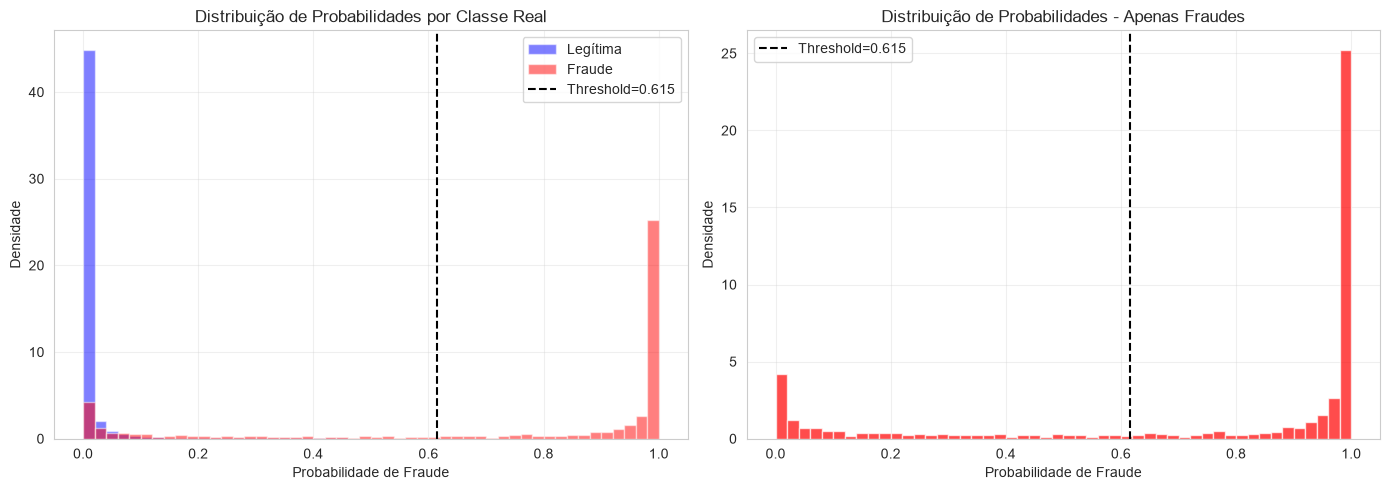

In [ ]:
# Distribuição de probabilidades
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por classe real
legit_proba = y_pred_proba[y_test == 0]
fraud_proba = y_pred_proba[y_test == 1]

axes[0].hist(legit_proba, bins=50, alpha=0.5, label='Legítima', density=True, color='blue')
axes[0].hist(fraud_proba, bins=50, alpha=0.5, label='Fraude', density=True, color='red')
axes[0].axvline(best_threshold, color='black', linestyle='--', label=f'Threshold={best_threshold:.3f}')
axes[0].set_xlabel('Probabilidade de Fraude')
axes[0].set_ylabel('Densidade')
axes[0].set_title('Distribuição de Probabilidades por Classe Real')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Zoom na região de fraude
axes[1].hist(fraud_proba, bins=50, alpha=0.7, color='red', density=True)
axes[1].axvline(best_threshold, color='black', linestyle='--', label=f'Threshold={best_threshold:.3f}')
axes[1].set_xlabel('Probabilidade de Fraude')
axes[1].set_ylabel('Densidade')
axes[1].set_title('Distribuição de Probabilidades - Apenas Fraudes')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Interpretabilidade com SHAP (Opcional)

Se `shap` estiver instalado, descomente a célula abaixo para gerar explicações SHAP.
Note que pode ser lento em datasets grandes.

In [ ]:
# SHAP Analysis (opcional - descomente se tiver shap instalado)
import shap

# Usar amostra menor para velocidade
sample_idx = np.random.choice(len(X_test), min(1000, len(X_test)), replace=False)
X_sample = X_test.iloc[sample_idx]

explainer = shap.TreeExplainer(model['model'])
shap_values = explainer.shap_values(X_sample)

# Summary plot
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean |SHAP|)')
plt.tight_layout()
plt.show()

# Beeswarm plot
shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP Beeswarm Plot')
plt.tight_layout()
plt.show()

ImportError: Numba needs NumPy 2.4 or less. Got NumPy 2.5.

## Resumo da Avaliação

- **ROC-AUC**: Métrica principal para problemas desbalanceados
- **PR-AUC**: Mais informativo quando classe positiva é rara
- **Threshold otimizado**: Ajustado para maximizar F1-Score
- **Feature Importance**: Identifica variáveis mais preditivas
- **Análise de erros**: Entende onde o modelo falha

### Próximos Passos
1. Ajuste de hiperparâmetros (Optuna/Hyperopt)
2. Ensemble de modelos
3. Calibração de probabilidades (Platt/Isotonic)
4. Monitoramento de drift em produção